In [1]:
from Bio import SeqIO
import json

g1 = "../data/hg38/hg38.ml.fa"
g1_records = {}
for record in SeqIO.parse(g1, "fasta"):
    g1_records[record.id] = record.seq

In [2]:
import json
g2_assembly = "../data/hg38/ncbi_dataset/data/GCF_000001405.26/sequence_report.jsonl"
data = []
with open(g2_assembly, "r") as f:
    for line in f:
        # Avoid empty lines
        if line.strip():  
            data.append(json.loads(line))

In [3]:
g2_id_to_g1_id = {}
for assembly in data:
    if assembly["ucscStyleName"] in g1_records:
        g2_id_to_g1_id[assembly["refseqAccession"]] = assembly["ucscStyleName"]

In [4]:
print(g2_id_to_g1_id)

{'NC_000001.11': 'chr1', 'NC_000002.12': 'chr2', 'NC_000003.12': 'chr3', 'NC_000004.12': 'chr4', 'NC_000005.10': 'chr5', 'NC_000006.12': 'chr6', 'NC_000007.14': 'chr7', 'NC_000008.11': 'chr8', 'NC_000009.12': 'chr9', 'NC_000010.11': 'chr10', 'NC_000011.10': 'chr11', 'NC_000012.12': 'chr12', 'NC_000013.11': 'chr13', 'NC_000014.9': 'chr14', 'NC_000015.10': 'chr15', 'NC_000016.10': 'chr16', 'NC_000017.11': 'chr17', 'NC_000018.10': 'chr18', 'NC_000019.10': 'chr19', 'NC_000020.11': 'chr20', 'NC_000021.9': 'chr21', 'NC_000022.11': 'chr22', 'NC_000023.11': 'chrX'}


In [13]:
import math

class OnlineStats:
    def __init__(self):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0   # suma acumulada de diferencias al cuadrado

    def update(self, x):
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n          # media actualizada
        delta2 = x - self.mean               # delta con la NUEVA media
        self.M2 += delta * delta2

    @property
    def variance_population(self):
        return self.M2 / self.n if self.n >= 1 else 0.0

    @property
    def variance_sample(self):
        return self.M2 / (self.n - 1) if self.n >= 2 else 0.0

    @property
    def std_population(self):
        return math.sqrt(self.variance_population)

    @property
    def std_sample(self):
        return math.sqrt(self.variance_sample)

In [74]:
from BCBio import GFF

gff_path = "../data/hg38/ncbi_dataset/data/GCF_000001405.26/genomic.gff"
limit_info = {
    #"gff_id": list(g2_id_to_g1_id.keys())
    "gff_id": ["NC_000001.11"]
}

reverse_orientation_features = {}
# Cita 1b
gtSkew = OnlineStats()

# Canonicalize so they're all in the + direction
with open(gff_path, "r") as f:
    for rec in GFF.parse(f, limit_info=limit_info):
        print(f"Parsing {rec.id}...")
        reverse_orientation_features[rec.id] = {"-": [], "+": []}
        for feature in rec.features:
            g1_id = g2_id_to_g1_id[rec.id]
            feature_seq = g1_records[g1_id][feature.location.start:feature.location.end]
            
            if feature.location.strand == -1:
                reverse_orientation_features[rec.id]["-"].append((feature.location.start, feature.location.end))
                skew = (feature_seq.count("C") + feature_seq.count("A") - feature_seq.count("G") - feature_seq.count("T")) / len(feature_seq)
            elif feature.location.strand == 1:
                reverse_orientation_features[rec.id]["+"].append((feature.location.start, feature.location.end))
                skew = (feature_seq.count("G") + feature_seq.count("T") - feature_seq.count("C") - feature_seq.count("A")) / len(feature_seq)

            gtSkew.update(skew)

Parsing NC_000001.11...


0.006967267818183366


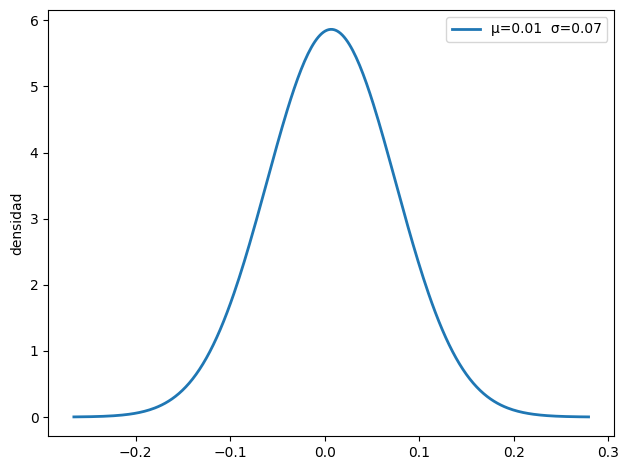

In [71]:
from matplotlib import pyplot as plt
import numpy as np

print(gtSkew.mean)

def plot_stats(stats):
    fig, ax = plt.subplots()

    mu  = stats.mean
    std = stats.std_sample
    x   = np.linspace(mu - 4*std, mu + 4*std, 300)
    y   = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / std) ** 2)
    ax.plot(x, y, linewidth=2, label=f"μ={mu:.2f}  σ={std:.2f}")

    ax.set_ylabel("densidad")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_stats(gtSkew)

In [77]:
# Take the complement, reverse and RC
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Seq import MutableSeq

def reverse(seq, start, end):
    seq[start:end] = seq[start:end][::-1]

def complement(seq, start, end):
    seq[start:end] = seq[start:end].complement()

def save_seqs_dict(seqs_dict, save_path):
    records = [
        SeqRecord(seq, id=name, description="")
        for name, seq in seqs_dict.items()
    ]
    SeqIO.write(records, save_path, "fasta")

test_seq = Seq("AACCGGTT")
rc_seq = MutableSeq(test_seq)
reverse(rc_seq, 0, 4)
complement(rc_seq, 0, 4)
print(test_seq, rc_seq)

AACCGGTT GGTTGGTT


AttributeError: 'str' object has no attribute 'reverse_complement'

In [62]:
reverse_seqs = {}
complement_seqs = {}
rc_seqs = {}

for g2_seq_id, locations in reverse_orientation_features.items():
    g1_id = g2_id_to_g1_id[g2_seq_id]
    print(f"Parsing {g1_id}...")
    
    reverse_seq = MutableSeq(g1_records[g1_id])
    complement_seq = MutableSeq(g1_records[g1_id])
    rc_seq = MutableSeq(g1_records[g1_id])
    
    for (start, end) in locations:
        reverse(reverse_seq, start, end)
        complement(complement_seq, start, end)

        reverse(rc_seq, start, end)
        complement(rc_seq, start, end)

    reverse_seqs[g1_id] = reverse_seq
    complement_seqs[g1_id] = complement_seq
    rc_seqs[g1_id] = rc_seq

Parsing chr1...
Parsing chr2...
Parsing chr3...
Parsing chr4...
Parsing chr5...
Parsing chr6...
Parsing chr7...
Parsing chr8...
Parsing chr9...
Parsing chr10...
Parsing chr11...
Parsing chr12...
Parsing chr13...
Parsing chr14...
Parsing chr15...
Parsing chr16...
Parsing chr17...
Parsing chr18...
Parsing chr19...
Parsing chr20...
Parsing chr21...
Parsing chr22...
Parsing chrX...


In [73]:
print(reverse_orientation_features["NC_000001.11"][0])

{'NC_000002.12': {'-': [(ExactPosition(38813), ExactPosition(46599)), (ExactPosition(218135), ExactPosition(264866)), (ExactPosition(279560), ExactPosition(288867)), (ExactPosition(490770), ExactPosition(492687)), (ExactPosition(667972), ExactPosition(677439)), (ExactPosition(779839), ExactPosition(868426)), (ExactPosition(900215), ExactPosition(905451)), (ExactPosition(949633), ExactPosition(952111)), (ExactPosition(1631886), ExactPosition(1744528)), (ExactPosition(1704859), ExactPosition(1708761)), (ExactPosition(1789112), ExactPosition(2331273)), (ExactPosition(2053975), ExactPosition(2186624)), (ExactPosition(2870557), ExactPosition(2871231)), (ExactPosition(2895047), ExactPosition(3126026)), (ExactPosition(3188969), ExactPosition(3377882)), (ExactPosition(3497918), ExactPosition(3519579)), (ExactPosition(3531812), ExactPosition(3534197)), (ExactPosition(3544891), ExactPosition(3558371)), (ExactPosition(3617137), ExactPosition(3617760)), (ExactPosition(3687780), ExactPosition(36890

In [73]:
print(g1_records["chr1"][14361])
print(complement_seqs["chr1"][14361])

T
A


In [75]:
out_path = "../data/parsed/"
save_seqs_dict(reverse_seqs, out_path / "reverse_seqs.fasta")
save_seqs_dict(complement_seqs, out_path / "complement_seqs.fasta")
save_seqs_dict(rc_seqs, out_path / "rc_seqs.fasta")